# Анализ данных RFSD (Russian Financial Statements Database)


## Описание задачи

В данной работе проводится разведочный анализ данных (EDA) финансовой отчётности российских компаний из открытого датасета [RFSD](https://github.com/irlcode/RFSD). Датасет содержит гармонизированные годовые неконсолидированные финансовые отчёты всех активных компаний России за 2011–2024 гг. (~60 млн строк, ~165 колонок).

**Цель:** выявить интересные закономерности, неожиданные связи и аномалии в финансовых данных.

**Методология:** из полного датасета отобрано 20 ключевых колонок, данные за 2023 год, фильтрация по признаку сдачи отчётности (filed==1), случайная выборка 10 000 компаний по всей РФ.

**Инструменты:** Polars (загрузка Parquet), Pandas, Matplotlib, Seaborn, SciPy.

## 0. Импорт библиотек

In [1]:
import os
import shutil
import warnings
import urllib.request
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

print("Библиотеки успешно импортированы.")

Библиотеки успешно импортированы.


## 1. Загрузка данных

Данные загружаются из [Hugging Face](https://huggingface.co/datasets/irlspbru/RFSD) в формате Parquet. Используется Polars `scan_parquet` для эффективного чтения.


In [2]:
SELECTED_COLUMNS = [
    'region', 'age', 'okved_section',
    'eligible', 'filed', 'simplified', 'outlier',
    'line_2110', 'line_2120', 'line_2100', 'line_2200', 'line_2400',
    'line_1150', 'line_1210', 'line_1230', 'line_1250',
    'line_1600', 'line_1700', 'line_1300',
]

COLUMN_NAMES = {
    'region': 'Регион', 'age': 'Возраст (лет)',
    'okved_section': 'Сектор ОКВЭД', 'eligible': 'Подлежит отчётности',
    'filed': 'Сдала отчёт', 'simplified': 'Упрощённая форма',
    'outlier': 'Флаг выброса',
    'line_2110': 'Выручка', 'line_2120': 'Себестоимость',
    'line_2100': 'Валовая прибыль', 'line_2200': 'Прибыль от продаж',
    'line_2400': 'Чистая прибыль',
    'line_1150': 'Основные средства', 'line_1210': 'Запасы',
    'line_1230': 'Дебиторская задолж.', 'line_1250': 'Денежные средства',
    'line_1600': 'Итого активы', 'line_1700': 'Итого обяз.+капитал',
    'line_1300': 'Итого капитал',
}

print(f"Выбрано {len(SELECTED_COLUMNS)} колонок.")

Выбрано 19 колонок.


In [3]:
LOCAL_FILE = 'part-0.parquet'
HF_URL = 'https://huggingface.co/datasets/irlspbru/RFSD/resolve/main/RFSD/year=2023/part-0.parquet'

if not os.path.exists(LOCAL_FILE):
    print('Скачивание файла из Hugging Face...')
    ok = False

    # Вариант 1: huggingface_hub
    try:
        from huggingface_hub import hf_hub_download
        downloaded = hf_hub_download(
            repo_id='irlspbru/RFSD',
            filename='RFSD/year=2023/part-0.parquet',
            repo_type='dataset'
        )
        shutil.copy2(downloaded, LOCAL_FILE)
        os.remove(downloaded)
        ok = True
        print('Скачано через huggingface_hub')
    except ImportError:
        print('huggingface_hub не установлен')
    except Exception as e:
        print(f'huggingface_hub ошибка: {e}')

    # Вариант 2: requests
    if not ok:
        try:
            import requests
            print('Скачивание через requests...')
            r = requests.get(HF_URL, stream=True, timeout=300)
            r.raise_for_status()
            with open(LOCAL_FILE, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
            ok = True
            print('Скачано через requests')
        except ImportError:
            print('requests не установлен')
        except Exception as e:
            print(f'requests ошибка: {e}')

    # Вариант 3: urllib + SSL отключение (для Mac)
    if not ok:
        import ssl
        ssl._create_default_https_context = ssl._create_unverified_context
        print('Скачивание через urllib (SSL проверка отключена)...')
        urllib.request.urlretrieve(HF_URL, LOCAL_FILE)
        print('Скачано через urllib')

# Проверка что файл — настоящий Parquet, а не HTML-страница ошибки
import pyarrow.parquet as pq
try:
    pf = pq.ParquetFile(LOCAL_FILE)
    print(f'Файл {LOCAL_FILE}: валидный Parquet, {pf.metadata.num_rows:,} строк, {pf.metadata.num_columns} колонок')
    print(f'Размер: {os.path.getsize(LOCAL_FILE) / (1024*1024):.1f} МБ')
except Exception as e:
    print(f'ОШИБКА: файл не является валидным Parquet! Удалите его и перезапустите ячейку.')
    print(f'Детали: {e}')

Скачивание файла из Hugging Face...
huggingface_hub не установлен
Скачивание через requests...
Скачано через requests
Файл part-0.parquet: валидный Parquet, 3,219,569 строк, 213 колонок
Размер: 528.9 МБ


In [4]:
# Чтение Parquet и фильтрация filed==1
print('Чтение Parquet...')

df_raw = pl.scan_parquet(LOCAL_FILE)

# Проверяем какие колонки реально есть
available = df_raw.collect_schema().names()
missing = [c for c in SELECTED_COLUMNS if c not in available]
if missing:
    print(f'ВНИМАНИЕ: колонок нет в файле: {missing}')
    print(f'Доступные колонки (первые 30): {available[:30]}')
    # Используем только те что есть
    use_cols = [c for c in SELECTED_COLUMNS if c in available]
else:
    use_cols = SELECTED_COLUMNS

df_raw = pl.scan_parquet(LOCAL_FILE).select(use_cols).filter(pl.col('filed') == 1).collect()

print(f'Всего сдавших отчёт: {df_raw.height:,} компаний')
if 'region' in df_raw.columns:
    print(f'Уникальных регионов: {df_raw["region"].n_unique()}')
print()

# Случайная выборка по всей России
SAMPLE_SIZE = 10_000
df_pl = df_raw.sample(n=SAMPLE_SIZE, seed=42)
del df_raw

print(f'Случайная выборка: {df_pl.height:,} компаний (seed=42)')
if 'region' in df_pl.columns:
    print(f'Регионы в выборке: {df_pl["region"].n_unique()}')
    print('Топ-5 регионов:')
    region_counts = df_pl.group_by('region').len().sort('len', descending=True)
    print(region_counts.head(5))

Чтение Parquet...
Всего сдавших отчёт: 2,278,600 компаний
Уникальных регионов: 90

Случайная выборка: 10,000 компаний (seed=42)
Регионы в выборке: 90
Топ-5 регионов:
shape: (5, 2)
┌──────────────────┬──────┐
│ region           ┆ len  │
│ ---              ┆ ---  │
│ str              ┆ u32  │
╞══════════════════╪══════╡
│ moscow city      ┆ 1661 │
│ sankt-petersburg ┆ 764  │
│ moscow reg.      ┆ 565  │
│ sverdlovsk       ┆ 374  │
│ krasnodar        ┆ 329  │
└──────────────────┴──────┘


### 1.1. Подготовка данных

- Переименование колонок на русский язык
- Заполнение пропусков в строках баланса нулями (для упрощённой формы отчётности пропуски означают нулевые остатки по данной статье)
- Добавление столбца `Год` (partition key, отсутствует в данных)
- Расчёт финансовых коэффициентов (рентабельность продаж, оборачиваемость активов)

In [5]:
# Переименование (strict=False — игнорирует отсутствующие колонки)
df_pl = df_pl.rename(COLUMN_NAMES, strict=False)

# Год (partition key)
df_pl = df_pl.with_columns(pl.lit(2023).alias('Год'))

# Пропуски в балансе = 0 (упрощённая форма)
balance_cols_rus = ['Основные средства', 'Запасы', 'Дебиторская задолж.',
                'Денежные средства', 'Итого активы', 'Итого обяз.+капитал', 'Итого капитал']
for col in balance_cols_rus:
    if col in df_pl.columns:
        df_pl = df_pl.with_columns(pl.col(col).fill_null(0))

# Конвертация в Pandas
df = df_pl.to_pandas()
del df_pl

# Типы — только для реально существующих колонок
all_numeric = ['Возраст (лет)', 'Подлежит отчётности', 'Сдала отчёт',
               'Упрощённая форма', 'Флаг выброса',
               'Выручка', 'Себестоимость', 'Валовая прибыль',
               'Прибыль от продаж', 'Чистая прибыль',
               'Основные средства', 'Запасы', 'Дебиторская задолж.',
               'Денежные средства', 'Итого активы',
               'Итого обяз.+капитал', 'Итого капитал']

numeric_cols = [c for c in all_numeric if c in df.columns]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

if 'Сектор ОКВЭД' in df.columns:
    df['Сектор ОКВЭД'] = df['Сектор ОКВЭД'].fillna('Не указан')

if 'Себестоимость' in df.columns:
    df['|Себестоимость|'] = df['Себестоимость'].abs()

print(f'Итоговый размер: {df.shape[0]:,} строк x {df.shape[1]} колонок')
print(f'Числовых колонок: {len(numeric_cols)}')

Итоговый размер: 10,000 строк x 21 колонок
Числовых колонок: 17


In [6]:
# Финансовые коэффициенты
df['Рентабельность продаж (%)'] = np.where(
    df['Выручка'].abs() > 0,
    (df['Чистая прибыль'] / df['Выручка'].abs()) * 100,
    np.nan
)

df['Оборачиваемость активов'] = np.where(
    df['Итого активы'].abs() > 0,
    df['Выручка'] / df['Итого активы'].abs(),
    np.nan
)

print('Финансовые коэффициенты рассчитаны:')
print(f'  Рентабельность продаж: медиана = {df["Рентабельность продаж (%)"].median():.1f}%')
print(f'  Оборачиваемость активов: медиана = {df["Оборачиваемость активов"].median():.2f}')

Финансовые коэффициенты рассчитаны:
  Рентабельность продаж: медиана = 3.0%
  Оборачиваемость активов: медиана = 1.47


## 2. Описательная статистика

Выведем описательную статистику для всех числовых колонок. Дополнительно показан процент пропусков.

In [7]:
desc_stats = df[numeric_cols].describe().T
desc_stats['missing_pct'] = (df[numeric_cols].isnull().sum() / len(df) * 100).round(1)
desc_stats['missing_pct'] = desc_stats['missing_pct'].astype(str) + '%'
desc_stats

,count,mean,std,min,25%,50%,75%,max,missing_pct
Возраст (лет),10000.0,10.148500,8.136011e+00,0.0,4.00,8.0,15.00,65.0,0.0%
Подлежит отчётности,10000.0,0.987200,1.124163e-01,0.0,1.00,1.0,1.00,1.0,0.0%
Сдала отчёт,10000.0,1.000000,0.000000e+00,1.0,1.00,1.0,1.00,1.0,0.0%
Упрощённая форма,10000.0,0.612100,4.872959e-01,0.0,0.00,1.0,1.00,1.0,0.0%
Флаг выброса,10000.0,0.000000,0.000000e+00,0.0,0.00,0.0,0.00,0.0,0.0%
Выручка,7438.0,175172.899032,3.067004e+06,-252.0,1380.25,9090.0,41423.50,228006729.0,25.6%
Себестоимость,7431.0,-140868.496030,2.554347e+06,-189348802.0,-34025.50,-6791.0,-900.50,0.0,25.7%
Валовая прибыль,2842.0,83857.442646,1.309539e+06,-4277279.0,63.25,1691.0,15084.00,54565439.0,71.6%
Прибыль от продаж,7600.0,15809.741579,4.758180e+05,-4758898.0,0.00,344.0,2486.50,38548025.0,24.0%
Чистая прибыль,8240.0,12198.504369,2.958947e+05,-4104139.0,0.00,129.0,1527.50,19441165.0,17.6%


### Вывод по описательной статистике

1. **Масштаб значений:** Финансовые показатели измеряются в тысячах рублей. Максимальные значения существенно превышают медианные — типичный признак логнормального распределения.

2. **Пропуски в строках баланса:** Столбцы `Основные средства`, `Запасы` и др. содержали пропуски, которые заполнены нулями — для упрощённой формы отчётности отсутствие значения означает нулевой остаток по статье. В разделе 5 проведён детальный анализ различий между полной и упрощённой формами.

3. **Возраст компаний:** Медианный возраст — около 10–12 лет, что отражает молодой возраст большинства российских предприятий.

4. **Выручка vs Себестоимость:** Обратите внимание, что медиана себестоимости **отрицательная** — в RFSD расходы хранятся со знаком минус по правилам РСБУ.

## 3. Гистограммы с обнаружением выбросов

Для трёх ключевых показателей строим гистограммы в **логарифмической шкале (log10)**, поскольку финансовые данные имеют логнормальное распределение. В линейной шкале все данные сгруппированы у нуля и график неинформативен (одна вертикальная полоса).

Красной пунктирной линией отмечена медиана.

### 3.1. Выручка (line_2110)

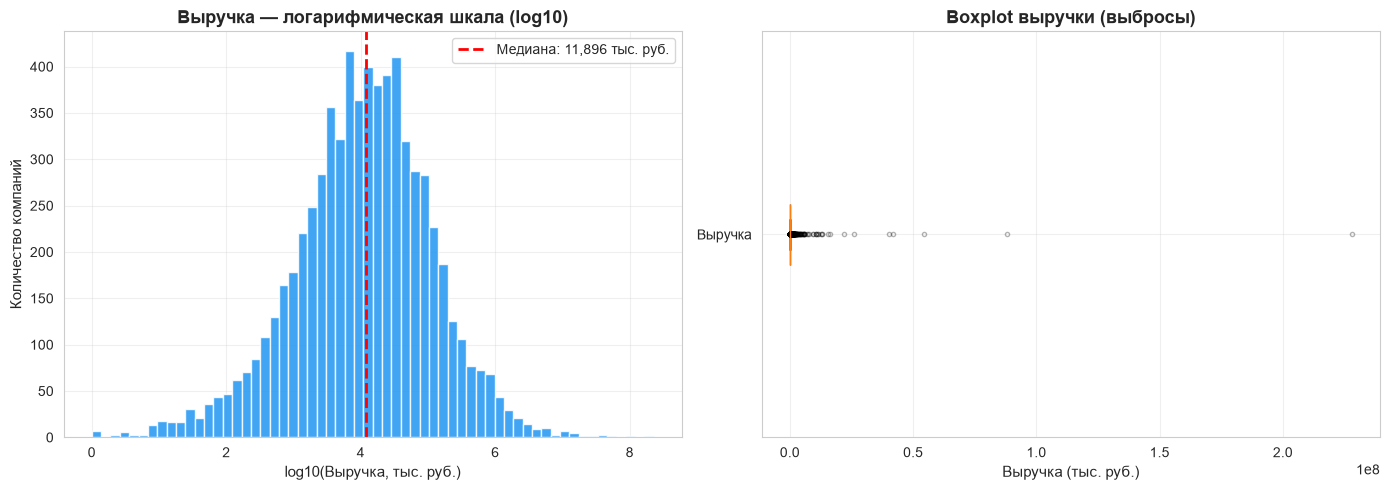

IQR: [2,617 — 48,323], границы: [-65,942 — 116,882]
Выбросы (IQR x 1.5): 921 компаний (13.6%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

revenue = df['Выручка'].dropna()
revenue_pos = revenue[revenue > 0]

# Левая панель: log10 шкала
axes[0].hist(np.log10(revenue_pos), bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(np.log10(revenue_pos.median()), color='red', linestyle='--', linewidth=2,
             label=f'Медиана: {revenue_pos.median():,.0f} тыс. руб.')
axes[0].set_title('Выручка — логарифмическая шкала (log10)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log10(Выручка, тыс. руб.)', fontsize=11)
axes[0].set_ylabel('Количество компаний', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Правая панель: boxplot
axes[1].boxplot(revenue_pos, vert=False, patch_artist=True,
             boxprops=dict(facecolor='#2196F3', alpha=0.6),
             flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title('Boxplot выручки (выбросы)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Выручка (тыс. руб.)', fontsize=11)
axes[1].set_yticklabels(['Выручка'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hist_revenue_log.png', bbox_inches='tight')
plt.show()

# IQR анализ
Q1 = revenue_pos.quantile(0.25)
Q3 = revenue_pos.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
n_out = ((revenue_pos < lower) | (revenue_pos > upper)).sum()
print(f'IQR: [{Q1:,.0f} — {Q3:,.0f}], границы: [{lower:,.0f} — {upper:,.0f}]')
print(f'Выбросы (IQR x 1.5): {n_out} компаний ({n_out/len(revenue_pos)*100:.1f}%)')


**Интерпретация:**

В логарифмической шкале распределение выручки становится approximately нормальным, что подтверждает логнормальную природу данных. В линейной шкале эта гистограмма выглядела бы как одна вертикальная линия у нуля — именно поэтому лог-шкала обязательна.

Boxplot наглядно показывает множество выбросов справа — это крупный бизнес, принципиально отличающийся по масштабу от большинства МСП. Доля выбросов по методу IQR x 1.5 значительна, что типично для логнормальных распределений.

### 3.2. Чистая прибыль (line_2400)

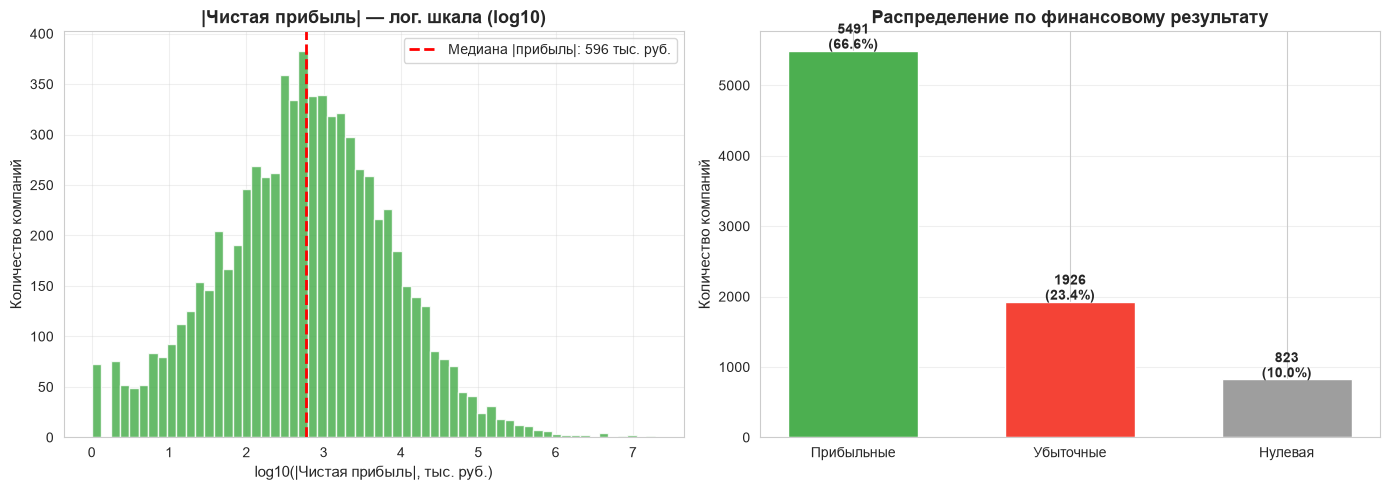

Прибыльных: 5491 (66.6%)
Убыточных:   1926 (23.4%)
Нулевых:     823 (10.0%)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

net_profit = df['Чистая прибыль'].dropna()

# Левая панель: log10 |прибыль|
profit_nz = net_profit[net_profit != 0]
profit_abs = profit_nz.abs()

axes[0].hist(np.log10(profit_abs), bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].axvline(np.log10(profit_abs.median()), color='red', linestyle='--', linewidth=2,
             label=f'Медиана |прибыль|: {profit_abs.median():,.0f} тыс. руб.')
axes[0].set_title('|Чистая прибыль| — лог. шкала (log10)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log10(|Чистая прибыль|, тыс. руб.)', fontsize=11)
axes[0].set_ylabel('Количество компаний', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Правая панель: прибыльные vs убыточные
n_prof = (net_profit > 0).sum()
n_loss = (net_profit < 0).sum()
n_zero = (net_profit == 0).sum()

bar_labels = ['Прибыльные', 'Убыточные', 'Нулевая']
bar_vals = [n_prof, n_loss, n_zero]
bar_colors = ['#4CAF50', '#F44336', '#9E9E9E']
axes[1].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='white', width=0.6)
axes[1].set_title('Распределение по финансовому результату', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Количество компаний', fontsize=11)
for i, (lbl, val) in enumerate(zip(bar_labels, bar_vals)):
    pct = val / len(net_profit) * 100
    axes[1].text(i, val + 30, f'{val}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hist_net_profit.png', bbox_inches='tight')
plt.show()

print(f'Прибыльных: {n_prof} ({n_prof/len(net_profit)*100:.1f}%)')
print(f'Убыточных:   {n_loss} ({n_loss/len(net_profit)*100:.1f}%)')
print(f'Нулевых:     {n_zero} ({n_zero/len(net_profit)*100:.1f}%)')


**Интерпретация:**

Абсолютные значения чистой прибыли также имеют логнормальное распределение. Правая панель показывает соотношение прибыльных и убыточных компаний. Доля убыточных компаний (обычно 25–35%) является нормальной для российской экономики и отражает естественную конкуренцию и циклические спады в отдельных отраслях.

### 3.3. Итого активы (line_1600)

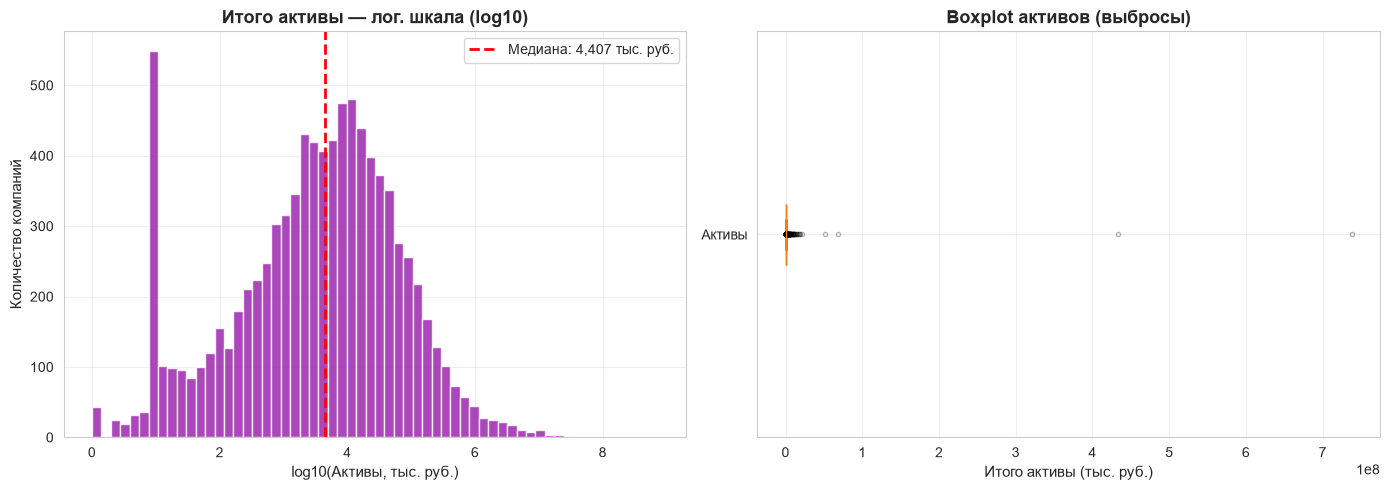

Медиана активов: 4,407 тыс. руб.
Выбросы по активам: 1343 компаний (14.8%)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

assets = df['Итого активы'].dropna()
assets_pos = assets[assets > 0]

# Левая панель: log10 шкала
axes[0].hist(np.log10(assets_pos), bins=60, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[0].axvline(np.log10(assets_pos.median()), color='red', linestyle='--', linewidth=2,
             label=f'Медиана: {assets_pos.median():,.0f} тыс. руб.')
axes[0].set_title('Итого активы — лог. шкала (log10)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log10(Активы, тыс. руб.)', fontsize=11)
axes[0].set_ylabel('Количество компаний', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Правая панель: boxplot
axes[1].boxplot(assets_pos, vert=False, patch_artist=True,
             boxprops=dict(facecolor='#9C27B0', alpha=0.6),
             flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title('Boxplot активов (выбросы)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Итого активы (тыс. руб.)', fontsize=11)
axes[1].set_yticklabels(['Активы'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hist_assets.png', bbox_inches='tight')
plt.show()

Q1_a = assets_pos.quantile(0.25)
Q3_a = assets_pos.quantile(0.75)
IQR_a = Q3_a - Q1_a
n_out_a = ((assets_pos < Q1_a - 1.5*IQR_a) | (assets_pos > Q3_a + 1.5*IQR_a)).sum()
print(f'Медиана активов: {assets_pos.median():,.0f} тыс. руб.')
print(f'Выбросы по активам: {n_out_a} компаний ({n_out_a/len(assets_pos)*100:.1f}%)')


**Интерпретация:**

Распределение активов также логнормальное с выраженным правым хвостом. Небольшая группа крупных компаний обладает активами, на порядки превышающими медианное значение. Обратите внимание: после заполнения пропусков нулями (для упрощённой формы) появляется пик у log10(0), поэтому мы анализируем только компании с активами > 0.

## 4. Обнаружение аномалий

Помимо стандартного IQR (показанного выше), проведём целенаправленный поиск специфических аномалий, характерных для финансовых данных.

In [11]:
anomalies = []

# Аномалия 1: Отрицательные основные средства
neg_assets = df[df['Основные средства'] < 0]
anomalies.append(('Отрицательные осн. средства', len(neg_assets)))

# Аномалия 2: Отрицательные денежные средства
neg_cash = df[df['Денежные средства'] < 0]
anomalies.append(('Отрицательные ден. средства', len(neg_cash)))

# Аномалия 3: Нулевая выручка при значительных активах (> 1 млн тыс. руб.)
zero_rev = df[(df['Выручка'] == 0) & (df['Итого активы'] > 1_000_000)]
anomalies.append(('Нулевая выручка + активы > 1 млн', len(zero_rev)))

# Аномалия 4: Выручка > 100x себестоимости
high_margin = df[(df['Выручка'].abs() > 0) & (df['Себестоимость'].abs() > 0) &
                 (df['Выручка'].abs() / df['Себестоимость'].abs() > 100)]
anomalies.append(('Выручка > 100x себестоимость', len(high_margin)))

# Аномалия 5: Отрицательный капитал (тех. банкрот)
neg_equity = df[(df['Итого капитал'] < 0) & (df['Итого активы'] > 0)]
anomalies.append(('Отрицательный капитал', len(neg_equity)))

print('=' * 55)
print('  ОБНАРУЖЕННЫЕ АНОМАЛИИ')
print('=' * 55)
for name, count in anomalies:
    pct = count / len(df) * 100
    print(f'  {name:40s}: {count:6d} ({pct:5.2f}%)')
print('=' * 55)


  ОБНАРУЖЕННЫЕ АНОМАЛИИ
  Отрицательные осн. средства             :      2 ( 0.02%)
  Отрицательные ден. средства             :     17 ( 0.17%)
  Нулевая выручка + активы > 1 млн        :      4 ( 0.04%)
  Выручка > 100x себестоимость            :     29 ( 0.29%)
  Отрицательный капитал                   :   1373 (13.73%)


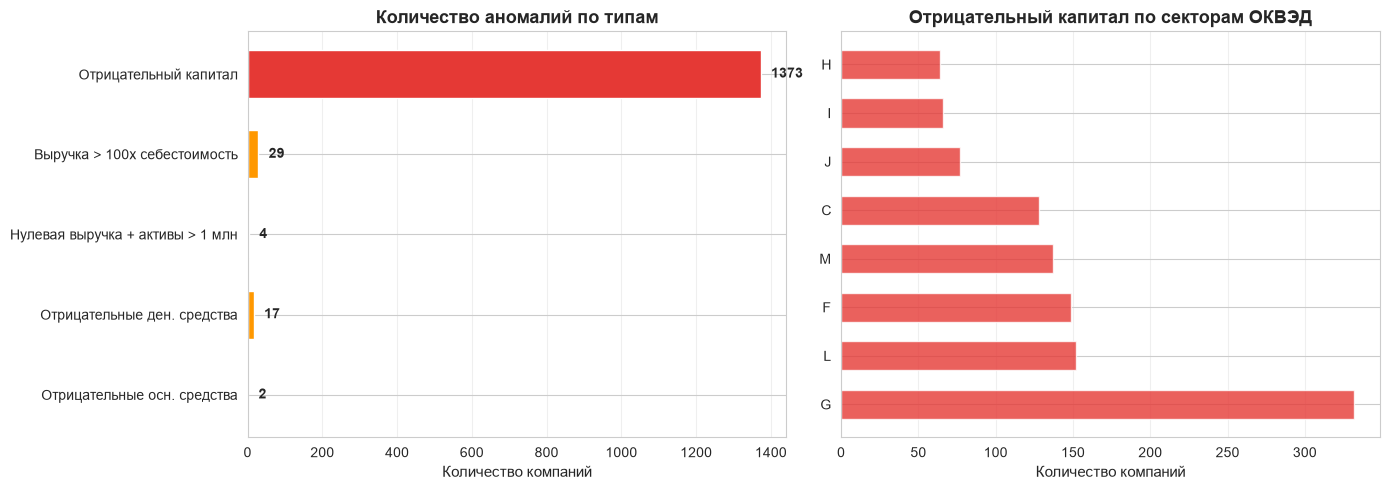

In [12]:
# Визуализация аномалий
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барчарт аномалий
names = [a[0] for a in anomalies]
counts = [a[1] for a in anomalies]
colors_anom = ['#e53935' if c > 50 else '#FF9800' for c in counts]
axes[0].barh(names, counts, color=colors_anom, edgecolor='white', height=0.6)
axes[0].set_title('Количество аномалий по типам', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Количество компаний', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
for i, (n, c) in enumerate(zip(names, counts)):
    axes[0].text(c + max(counts)*0.02, i, str(c), va='center', fontsize=10, fontweight='bold')

# Отрицательный капитал по секторам
if len(neg_equity) > 0:
    sec_anom = neg_equity['Сектор ОКВЭД'].value_counts().head(8)
    axes[1].barh(sec_anom.index, sec_anom.values, color='#e53935', alpha=0.8,
                 edgecolor='white', height=0.6)
    axes[1].set_title('Отрицательный капитал по секторам ОКВЭД', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Количество компаний', fontsize=11)
    axes[1].grid(axis='x', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Нет компаний с отрицательным капиталом',
                 ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('anomalies.png', bbox_inches='tight')
plt.show()


**Интерпретация:**

Обнаруженные аномалии представляют не просто «грязные данные», а информативный сигнал:

1. **Отрицательные активы/денежные средства** — возможны ошибки учёта или специфические ситуации (переоценка, обесценение, овердрафт).

2. **Нулевая выручка при крупных активах** — компании-холдинги, dormant entities или компании в процессе ликвидации, которые ещё не закрыли баланс.

3. **Отрицательный капитал** — технически неплатёжеспособные компании. Распределение по секторам показывает, где концентрация финансовых проблем наибольшая.

## 5. Корреляционная матрица (Spearman)

Используем **ранговую корреляцию Спирмена** вместо Пирсона, поскольку финансовые данные имеют логнормальное распределение и содержат выбросы. Спирмен устойчив к ненормальности и экстремальным значениям.

> **Важное замечание:** В RFSD себестоимость (line_2120) хранится **отрицательной** > по правилам российской бухгалтерии. Для корреляции используем `|Себестоимость|`.

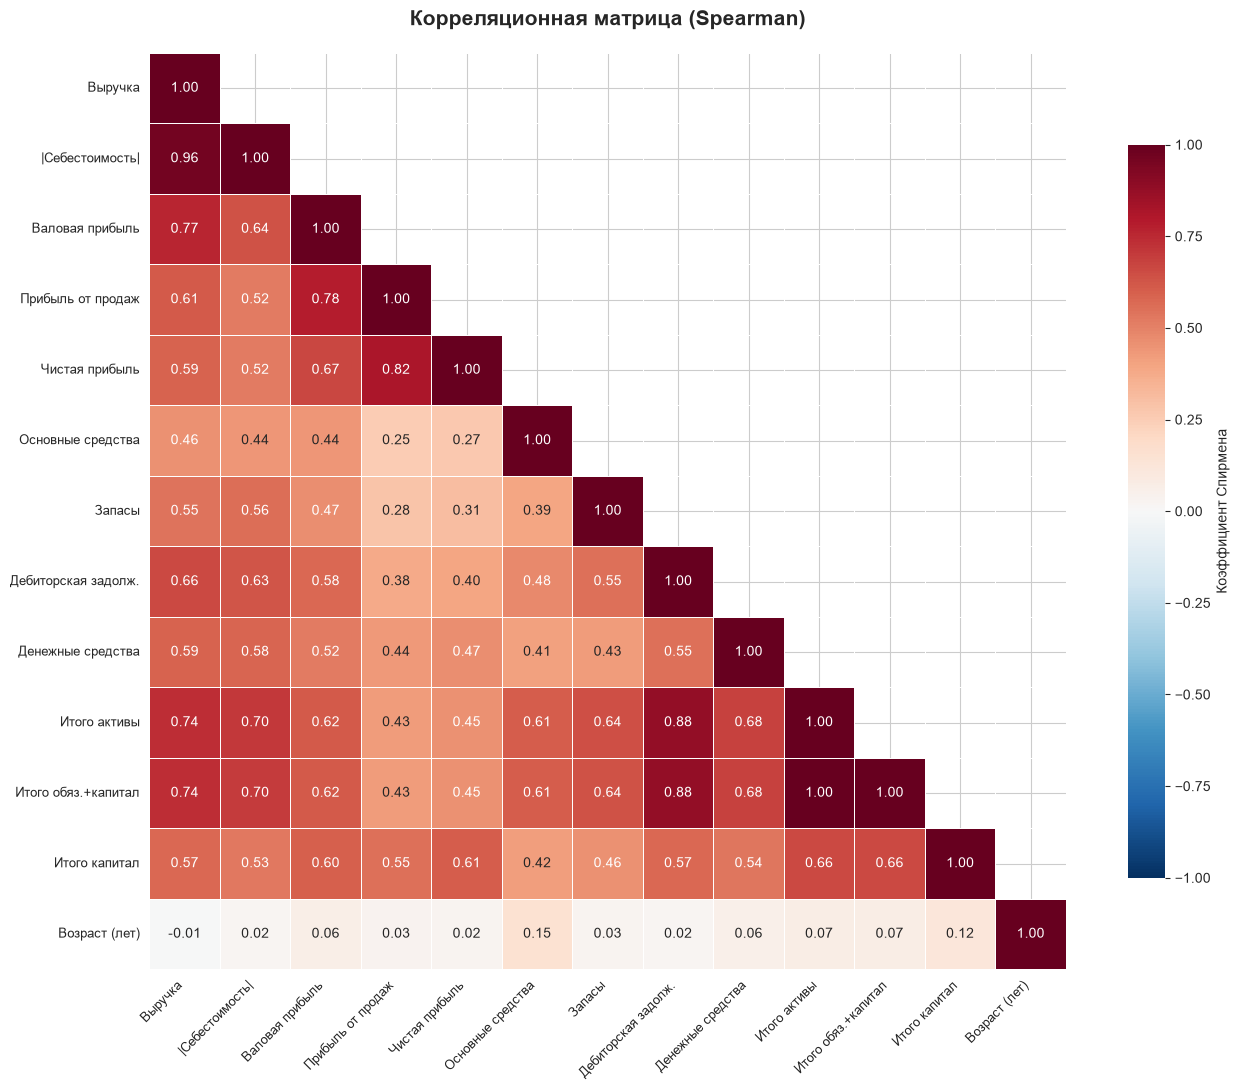

In [13]:
corr_cols = ['Выручка', '|Себестоимость|', 'Валовая прибыль', 'Прибыль от продаж',
             'Чистая прибыль', 'Основные средства', 'Запасы',
             'Дебиторская задолж.', 'Денежные средства',
             'Итого активы', 'Итого обяз.+капитал', 'Итого капитал', 'Возраст (лет)']

corr_matrix = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Коэффициент Спирмена'})
plt.title('Корреляционная матрица (Spearman)', fontsize=15, fontweight='bold', pad=20)
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

In [14]:
high_corr = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.7:
            high_corr.append((corr_cols[i], corr_cols[j], rho))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
print('Пары с высокой корреляцией (|Spearman rho| > 0.7):')
print()
for c1, c2, r in high_corr:
    print(f'  {c1:25s} <-> {c2:25s}: rho = {r:.3f}')
print()
print(f'Всего пар с |rho| > 0.7: {len(high_corr)}')
print(f'Всего пар с |rho| > 0.5: {sum(1 for i in range(len(corr_cols)) for j in range(i+1, len(corr_cols)) if abs(corr_matrix.iloc[i,j]) > 0.5)}')

Пары с высокой корреляцией (|Spearman rho| > 0.7):

  Итого активы              <-> Итого обяз.+капитал      : rho = 0.999
  Выручка                   <-> |Себестоимость|          : rho = 0.963
  Дебиторская задолж.       <-> Итого активы             : rho = 0.882
  Дебиторская задолж.       <-> Итого обяз.+капитал      : rho = 0.881
  Прибыль от продаж         <-> Чистая прибыль           : rho = 0.816
  Валовая прибыль           <-> Прибыль от продаж        : rho = 0.783
  Выручка                   <-> Валовая прибыль          : rho = 0.765
  Выручка                   <-> Итого активы             : rho = 0.737
  Выручка                   <-> Итого обяз.+капитал      : rho = 0.737
  |Себестоимость|           <-> Итого активы             : rho = 0.703
  |Себестоимость|           <-> Итого обяз.+капитал      : rho = 0.703

Всего пар с |rho| > 0.7: 11
Всего пар с |rho| > 0.5: 44


### Анализ корреляционной матрицы

**1. Знак расходов в РСБУ:** В RFSD себестоимость (line_2120) хранится **отрицательной**. Без взятия модуля корреляция Выручка <-> Себестоимость была бы spuriously отрицательной (~-0.99). После `abs()` видим ожидаемую сильную положительную корреляцию.

**2. Бухгалтерское тождество:** `Итого активы` и `Итого обяз.+капитал` коррелируют с rho ~ 1.0 — это фундаментальное тождество Активы = Обязательства + Капитал, а не ошибка. При построении моделей одну из переменных следует исключить.

**3. Возраст не коррелирует с финансами:** |rho| < 0.1 для всех пар с возрастом — старые компании не обязательно крупнее или прибыльнее молодых.

## 6. Диаграммы рассеивания

Построим диаграммы для наиболее коррелирующих пар. Оси ограничены 98-м перцентилем для наглядности.

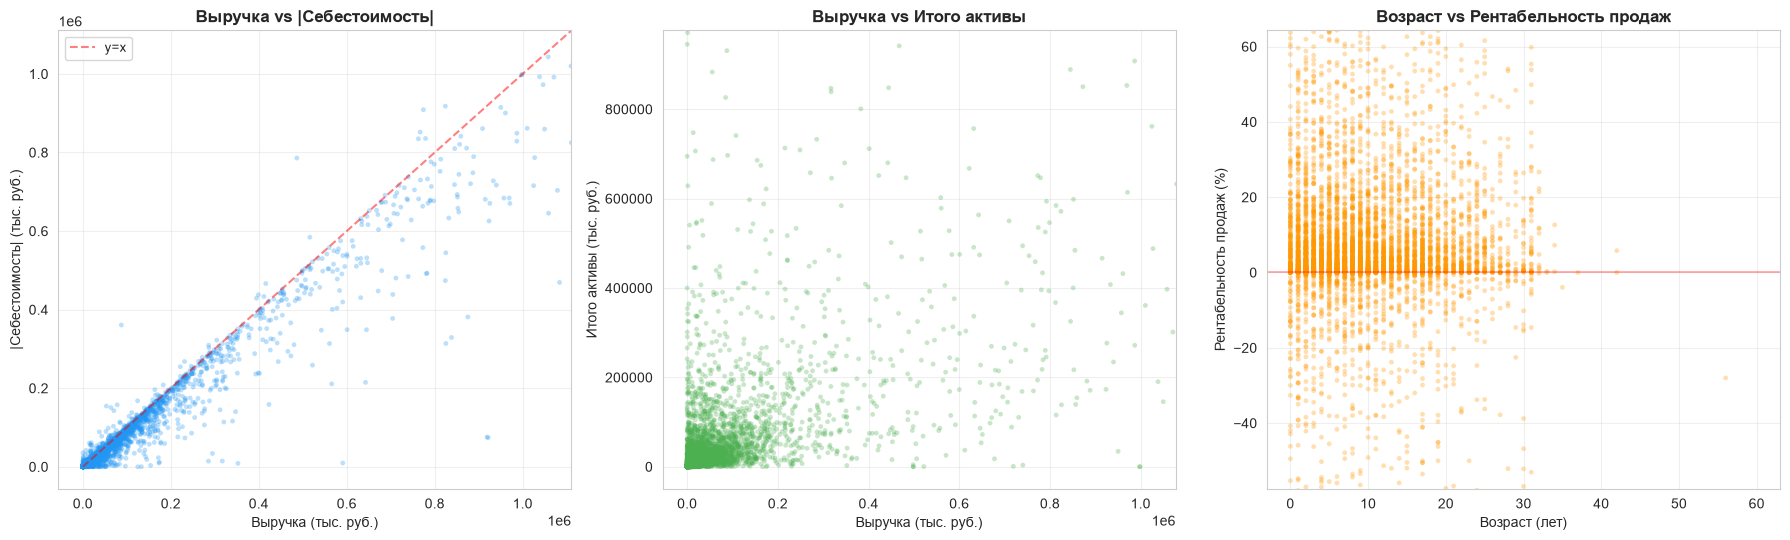

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1) Выручка vs |Себестоимость|
ax = axes[0]
v = df[(df['Выручка'] > 0) & (df['|Себестоимость|'] > 0)]
ax.scatter(v['Выручка'], v['|Себестоимость|'], alpha=0.3, s=12, color='#2196F3', edgecolors='none')
ax.set_title('Выручка vs |Себестоимость|', fontsize=12, fontweight='bold')
ax.set_xlabel('Выручка (тыс. руб.)', fontsize=10)
ax.set_ylabel('|Себестоимость| (тыс. руб.)', fontsize=10)
ax.grid(alpha=0.3)
lim = v['Выручка'].quantile(0.98)
ax.set_xlim(-lim*0.05, lim)
ax.set_ylim(-lim*0.05, lim)
ax.plot([0, lim], [0, lim], 'r--', alpha=0.5, label='y=x')
ax.legend(fontsize=9)

# 2) Выручка vs Итого активы
ax = axes[1]
v2 = df[(df['Выручка'] > 0) & (df['Итого активы'] > 0)]
ax.scatter(v2['Выручка'], v2['Итого активы'], alpha=0.3, s=12, color='#4CAF50', edgecolors='none')
ax.set_title('Выручка vs Итого активы', fontsize=12, fontweight='bold')
ax.set_xlabel('Выручка (тыс. руб.)', fontsize=10)
ax.set_ylabel('Итого активы (тыс. руб.)', fontsize=10)
ax.grid(alpha=0.3)
lx = v2['Выручка'].quantile(0.98)
ly = v2['Итого активы'].quantile(0.98)
ax.set_xlim(-lx*0.05, lx)
ax.set_ylim(-ly*0.05, ly)

# 3) Возраст vs Рентабельность продаж
ax = axes[2]
v3 = df[df['Рентабельность продаж (%)'].notna()]
ax.scatter(v3['Возраст (лет)'], v3['Рентабельность продаж (%)'], alpha=0.3, s=12, color='#FF9800', edgecolors='none')
ax.set_title('Возраст vs Рентабельность продаж', fontsize=12, fontweight='bold')
ax.set_xlabel('Возраст (лет)', fontsize=10)
ax.set_ylabel('Рентабельность продаж (%)', fontsize=10)
ax.grid(alpha=0.3)
ax.axhline(0, color='red', linestyle='-', alpha=0.3)
pcap = v3['Рентабельность продаж (%)'].quantile(0.95)
lcap = v3['Рентабельность продаж (%)'].quantile(0.05)
ax.set_ylim(lcap, pcap)

plt.tight_layout()
plt.savefig('scatter_plots.png', bbox_inches='tight')
plt.show()

### Анализ диаграмм рассеивания

**1. Выручка vs |Себестоимость|:** Практически линейная зависимость вдоль диагонали y=x. Себестоимость составляет значительную долю выручки. Точки выше диагонали — убыточные предприятия.

**2. Выручка vs Активы:** Связь положительная, но с большим разбросом — некоторые компании с крупными активами генерируют небольшую выручку (низкая эффективность).

**3. Возраст vs Рентабельность:** Отсутствие значимой зависимости. Компании всех возрастов демонстрируют широкий разброс рентабельности (согласуется с корреляцией |rho| < 0.1).

## 7. Анализ по секторам ОКВЭД

Сгруппируем данные по секторам ОКВЭД для выявления отраслевых различий в выручке, рентабельности и доле убыточных компаний.

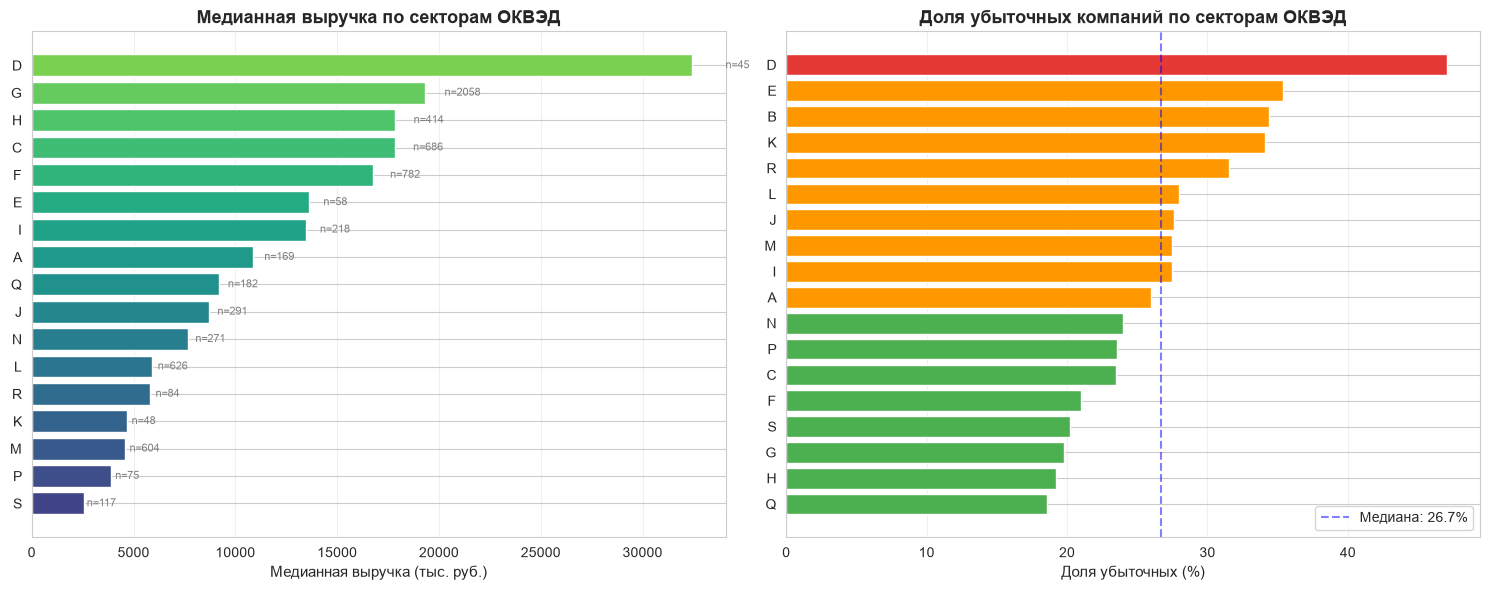

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Медианная выручка по секторам
sec_rev = (df[df['Выручка'] > 0]
    .groupby('Сектор ОКВЭД')['Выручка']
    .agg(['median', 'count'])
    .sort_values('median', ascending=True))
sec_rev = sec_rev[sec_rev['count'] >= 30]

colors_s = plt.cm.viridis(np.linspace(0.2, 0.8, len(sec_rev)))
axes[0].barh(sec_rev.index, sec_rev['median'], color=colors_s, edgecolor='white')
axes[0].set_title('Медианная выручка по секторам ОКВЭД', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Медианная выручка (тыс. руб.)', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
for i, (idx, row) in enumerate(sec_rev.iterrows()):
    axes[0].text(row['median'] * 1.05, i, 'n=' + str(int(row['count'])),
                 va='center', fontsize=8, color='gray')

# Доля убыточных
sec_loss = (df.groupby('Сектор ОКВЭД')['Чистая прибыль']
    .apply(lambda x: (x < 0).sum() / x.notna().sum() * 100 if x.notna().sum() > 0 else 0)
    .sort_values(ascending=True))
sec_cnt = df.groupby('Сектор ОКВЭД').size()
sec_loss = sec_loss[sec_cnt >= 30]

cl = ['#e53935' if v > 40 else '#FF9800' if v > 25 else '#4CAF50' for v in sec_loss.values]
axes[1].barh(sec_loss.index, sec_loss.values, color=cl, edgecolor='white')
axes[1].set_title('Доля убыточных компаний по секторам ОКВЭД', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Доля убыточных (%)', fontsize=11)
axes[1].axvline(sec_loss.median(), color='blue', linestyle='--', alpha=0.5,
             label='Медиана: ' + str(round(sec_loss.median(), 1)) + '%')
axes[1].legend(fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('sector_revenue.png', bbox_inches='tight')
plt.show()

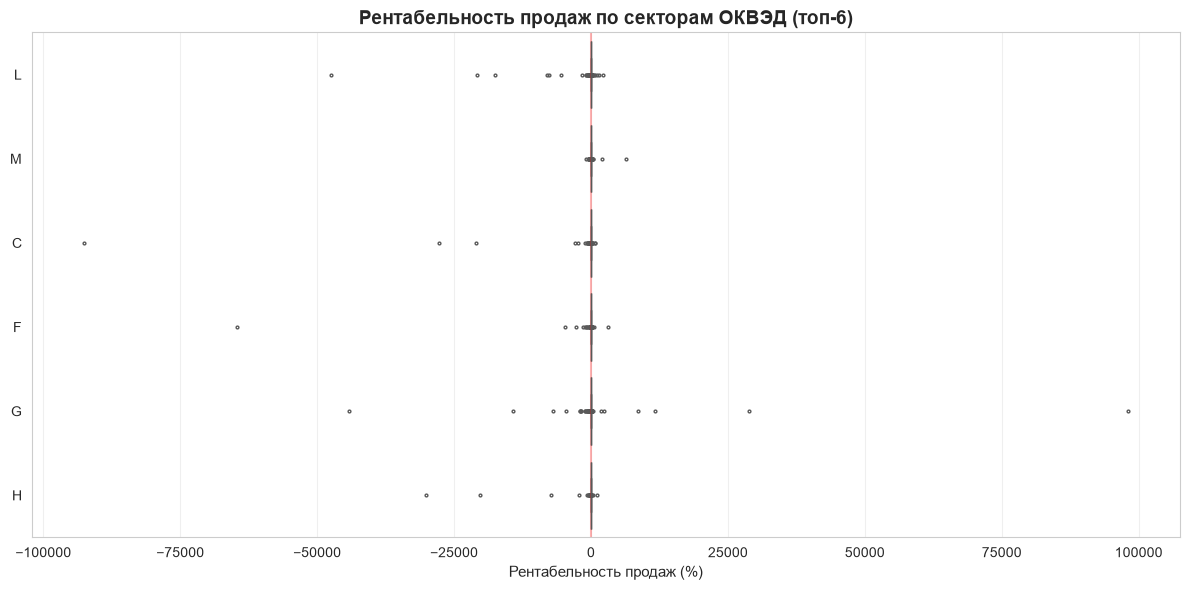

In [17]:
# Boxplot: рентабельность продаж по топ-6 секторам
top_sec = df['Сектор ОКВЭД'].value_counts().head(6).index.tolist()
df_top = df[df['Сектор ОКВЭД'].isin(top_sec) & df['Рентабельность продаж (%)'].notna()]
order = df_top.groupby('Сектор ОКВЭД')['Рентабельность продаж (%)'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, y='Сектор ОКВЭД', x='Рентабельность продаж (%)',
            order=order, palette='Set2', fliersize=2)
plt.title('Рентабельность продаж по секторам ОКВЭД (топ-6)', fontsize=14, fontweight='bold')
plt.xlabel('Рентабельность продаж (%)', fontsize=11)
plt.ylabel('')
plt.axvline(0, color='red', linestyle='-', alpha=0.3)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('sector_profitability_boxplot.png', bbox_inches='tight')
plt.show()

### Анализ по секторам ОКВЭД

1. **Медианная выручка** существенно варьируется: секторы с капиталоёмким производством (C) и оптовой торговлей (G) демонстрируют наибольшие масштабы, а сфера услуг (S) — наименьшие.

2. **Доля убыточных компаний** заметно различается. Красным выделены секторы с долей > 40%, что может свидетельствовать о структурных проблемах или высокой конкуренции.

3. **Boxplot рентабельности** показывает огромный внутриотраслевой разброс: межквартильный размах практически во всех секторах перекрывает нулевую отметку, что означает наличие как глубоко убыточных, так и высокомаржинальных компаний внутри каждого сектора.

## 8. Анализ упрощённой формы отчётности

Компании делятся на две группы по форме отчётности: `simplified == 1` (упрощённая) и `simplified == 0` (полная). Упрощённая форма содержит меньше статей баланса, что объясняет пропуски, отмеченные в разделе 2.

In [18]:
# Сравнение полной и упрощённой форм
simp = df['Упрощённая форма'].value_counts()
print('Распределение по форме отчётности:')
print(f'  Полная форма (0): {simp.get(0, 0):,} компаний ({simp.get(0, 0)/len(df)*100:.1f}%)')
print(f'  Упрощённая (1):  {simp.get(1, 0):,} компаний ({simp.get(1, 0)/len(df)*100:.1f}%)')
print()

compare_cols = ['Выручка', 'Чистая прибыль', 'Итого активы', 'Итого капитал']
full = df[df['Упрощённая форма'] == 0][compare_cols].median()
simple = df[df['Упрощённая форма'] == 1][compare_cols].median()

comparison = pd.DataFrame({
    'Полная форма': full,
    'Упрощённая форма': simple,
    'Разница (разы)': (full / simple.abs().replace(0, np.nan)).round(1)
})
comparison

Распределение по форме отчётности:
  Полная форма (0): 3,879 компаний (38.8%)
  Упрощённая (1):  6,121 компаний (61.2%)



,Полная форма,Упрощённая форма,Разница (разы)
Выручка,15168.0,6948.0,2.2
Чистая прибыль,156.0,114.0,1.4
Итого активы,4003.0,2639.0,1.5
Итого капитал,567.0,311.0,1.8


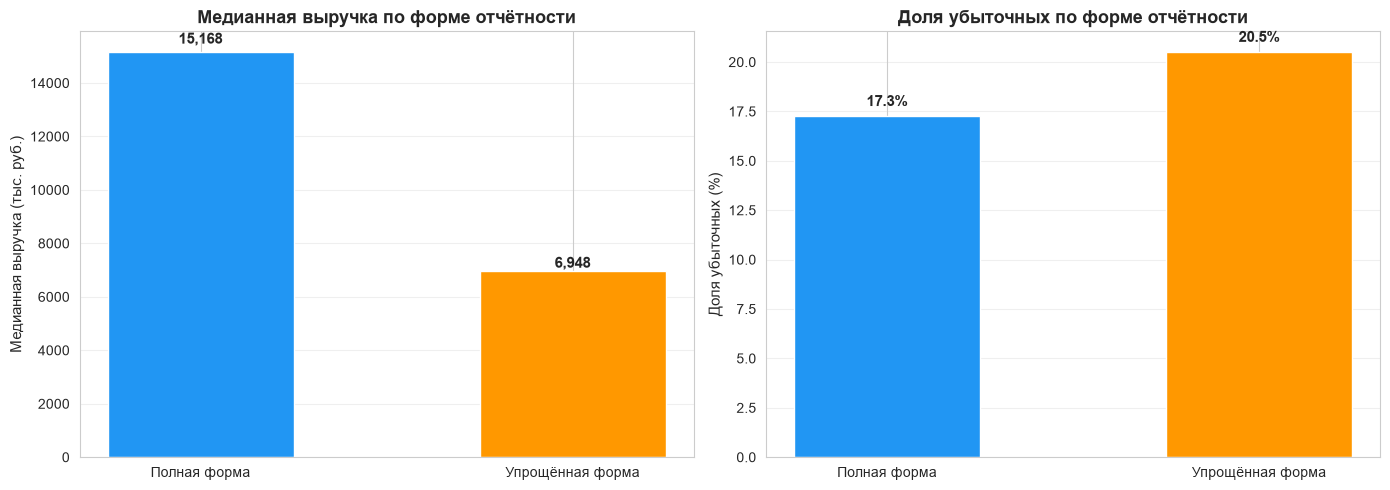

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

med_rev_full = df[df['Упрощённая форма'] == 0]['Выручка'].median()
med_rev_simp = df[df['Упрощённая форма'] == 1]['Выручка'].median()
bars = axes[0].bar(['Полная форма', 'Упрощённая форма'],
                    [med_rev_full, med_rev_simp],
                    color=['#2196F3', '#FF9800'], edgecolor='white', width=0.5)
axes[0].set_title('Медианная выручка по форме отчётности', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Медианная выручка (тыс. руб.)', fontsize=11)
for bar, val in zip(bars, [med_rev_full, med_rev_simp]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                f'{val:,.0f}', ha='center', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

loss_full = (df[df['Упрощённая форма'] == 0]['Чистая прибыль'] < 0).mean() * 100
loss_simp = (df[df['Упрощённая форма'] == 1]['Чистая прибыль'] < 0).mean() * 100
bars2 = axes[1].bar(['Полная форма', 'Упрощённая форма'],
                     [loss_full, loss_simp],
                     color=['#2196F3', '#FF9800'], edgecolor='white', width=0.5)
axes[1].set_title('Доля убыточных по форме отчётности', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Доля убыточных (%)', fontsize=11)
for bar, val in zip(bars2, [loss_full, loss_simp]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('simplified_comparison.png', bbox_inches='tight')
plt.show()

### Вывод по упрощённой форме

Компании на упрощённой форме — это, как правило, малые предприятия (МСП) с существенно меньшими масштабами деятельности. Их медианная выручка и активы значительно ниже, чем у компаний на полной форме. Именно поэтому пропуски в строках баланса не являются ошибкой данных, а отражают специфику упрощённой отчётности, где многие статьи просто не заполняются (и мы корректно заменили их нулями в разделе 1.1). Доля убыточных компаний может различаться между формами, что отражает различную структуру затрат и налоговую нагрузку.

## 9. Общие выводы

На основе проведённого анализа данных RFSD выявлены следующие ключевые закономерности:

### Вывод 1: Логнормальное распределение финансовых показателей

Все финансовые показатели (выручка, прибыль, активы) имеют **правоскошенное логнормальное распределение**. В линейной шкале гистограммы неинформативны, поэтому для визуализации обязательно использование логарифмической шкалы (log10). Это фундаментальное свойство финансовых данных, связанное с мультипликативным характером экономических процессов.

### Вывод 2: Специфика российских финансовых данных

В RFSD расходы (себестоимость, line_2120) хранятся **отрицательными** по правилам РСБУ. Без учёта этой специфики корреляционный анализ даёт ложные результаты. Пропуски в строках баланса означают нулевые значения для упрощённой формы отчётности.

### Вывод 3: Бухгалтерское тождество и мультиколлинеарность

Корреляция `Итого активы` <-> `Итого обяз.+капитал` близка к 1.0 (Spearman rho), что отражает фундаментальное тождество Активы = Обязательства + Капитал. При построении моделей одну из переменных следует исключить для избежания мультиколлинеарности.

### Вывод 4: Возраст не определяет финансовый успех

Возраст компании практически не коррелирует ни с одним финансовым показателем (|rho| < 0.1). На диаграмме рассеивания не наблюдается тренда — конкурентное преимущество определяется не стажем, а бизнес-моделью и рыночной позицией.

### Вывод 5: Значительная отраслевая вариация

Секторы ОКВЭД существенно различаются по медианной выручке и доле убыточных компаний. Однако внутриотраслевой разброс рентабельности огромен и перекрывает межотраслевые различия.

### Вывод 6: Аномалии как информативный сигнал

Обнаруженные аномалии (отрицательные активы, отрицательный капитал, нулевая выручка при крупных активах) представляют информативный сигнал о финансовом состоянии — технические банкроты, dormant entities, ошибки учёта.

### Ограничения исследования

- Выборка ограничена 10 000 компаний за 2023 год (один год из 14 доступных). - Используется только один Parquet-файл (part-0), содержащий часть данных за год. - Для более глубоких выводов необходим анализ временных рядов и большего объёма данных.